# NEOFC - Compare MRI and MEG data

In [1]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl
from tqdm.auto import tqdm
import seaborn as sn
import pickle, gzip
from scipy.stats import spearmanr

from utils import load_neofc_stats, sidak, meff_li_ji, load_pickled_mapconn

from nispace.stats.coloc import corr, partialcorr
from nispace.stats.misc import null_to_p


# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS_COLORS, REF_NAMES_PET, REF_GROUPS_PET, MEG_FQBANDS, REF_COLORS_BY_MAP,
                   REF_MATH_NAMES)

# colors
colors = REF_GROUPS_COLORS[1:]
colors_maps = [c for i, v in enumerate(REF_GROUPS_PET.values()) for c in [colors[i]]*len(v)]


/Users/llotter/projects/mapfc


## Data

In [2]:
parc = "Schaefer200"

### Mapconn objects: MRI

In [3]:
mapconn_ya_mri = load_pickled_mapconn("hcp_ya_mri", parcs=parc, dset="pet")

Loading pickled MapConn objects: 100%|██████████| 1/1 [00:05<00:00,  5.20s/it]


### Mapconn objects: MEG

In [4]:
mapconn_ya_meg = load_pickled_mapconn("hcp_ya_meg", parcs=parc)

Loading pickled MapConn objects: 100%|██████████| 1/1 [00:14<00:00, 14.17s/it]


### MapConn (NEOFC) stats: MRI

In [5]:
neofc_ya_mri_pet_groupstats, neofc_ya_mri_pet_indivstats = load_neofc_stats(
    "hcp_ya_mri", parc, dset="pet", stats="auc")
#display(neofc_ya_mri_pet_groupstats, neofc_ya_mri_pet_indivstats)

Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-pet_stat-..._group.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-pet_stat-..._individual.csv.gz


### MapConn (NEOFC) stats: MEG

In [6]:
neofc_ya_meg_pet_groupstats, neofc_ya_meg_pet_indivstats = load_neofc_stats(
    "hcp_ya_meg", parc, index_special=["fqband"], level=["group", "individual"], stats="auc")
#display(neofc_ya_meg_pet_groupstats, neofc_ya_meg_pet_indivstats)

Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_meg/parc-..._stat-..._group.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_meg/parc-..._stat-..._individual.csv.gz


### Subjects in both datasets

In [7]:
subs = np.intersect1d(
    neofc_ya_meg_pet_indivstats.index.get_level_values("id").unique(),
    neofc_ya_mri_pet_indivstats.index.get_level_values("id").unique()
)
print(f"Number of subjects in both datasets: {len(subs)}")

Number of subjects in both datasets: 29


## MRI vs. MEG

### AUC "fingerprint" correlation on individual level
Also calculate group-level averages and p values

In [8]:
neofc_ya_mrimeg_indivprofile = {}
neofc_ya_mrimeg_groupprofile = {}
stat = "auc" # run only for AUC stat
val = "val_rz" # use robust z values so as to limit the influence of spatial autocorrelation
val_group = "mean_rz"

# create dict of dataframes to compare
df_dict = {
    ("mri_original", "mri_inverted"): (
        neofc_ya_mri_pet_indivstats.loc[(parc, "pearson", "all", [1,2], "original", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_mri_pet_indivstats.loc[(parc, "pearson", "all", [1,2], "inverted", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], "original", stat, val_group), REF_NAMES_PET].mean(),
        neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], "inverted", stat, val_group), REF_NAMES_PET].mean()
    )
}
for fq in MEG_FQBANDS:
    # all options: AEC - pearson
    df_dict[f"meg-{fq}_original", f"meg-{fq}_inverted"] = (
        neofc_ya_meg_pet_indivstats.loc[(parc, "aec", "all", fq, "original", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_meg_pet_indivstats.loc[(parc, "aec", "all", fq, "inverted", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_meg_pet_groupstats.loc[(parc, "aec", "all", fq, "original", stat, val_group), REF_NAMES_PET],
        neofc_ya_meg_pet_groupstats.loc[(parc, "aec", "all", fq, "inverted", stat, val_group), REF_NAMES_PET]
    )
    df_dict["mri_original", f"meg-{fq}_original"] = (
        neofc_ya_mri_pet_indivstats.loc[(parc, "pearson", "all", [1,2], "original", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_meg_pet_indivstats.loc[(parc, "aec", "all", fq, "original", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], "original", stat, val_group), REF_NAMES_PET].mean(),
        neofc_ya_meg_pet_groupstats.loc[(parc, "aec", "all", fq, "original", stat, val_group), REF_NAMES_PET]
    )
    df_dict["mri_inverted", f"meg-{fq}_inverted"] = (
        neofc_ya_mri_pet_indivstats.loc[(parc, "pearson", "all", [1,2], "inverted", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_meg_pet_indivstats.loc[(parc, "aec", "all", fq, "inverted", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], "inverted", stat, val_group), REF_NAMES_PET].mean(),
        neofc_ya_meg_pet_groupstats.loc[(parc, "aec", "all", fq, "inverted", stat, val_group), REF_NAMES_PET]
    )
    df_dict["mri_original", f"meg-{fq}_inverted"] = (
        neofc_ya_mri_pet_indivstats.loc[(parc, "pearson", "all", [1,2], "original", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_meg_pet_indivstats.loc[(parc, "aec", "all", fq, "inverted", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], "original", stat, val_group), REF_NAMES_PET].mean(),
        neofc_ya_meg_pet_groupstats.loc[(parc, "aec", "all", fq, "inverted", stat, val_group), REF_NAMES_PET]
    )
    df_dict["mri_inverted", f"meg-{fq}_original"] = (
        neofc_ya_mri_pet_indivstats.loc[(parc, "pearson", "all", [1,2], "inverted", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_meg_pet_indivstats.loc[(parc, "aec", "all", fq, "original", stat, val, subs), REF_NAMES_PET].groupby("id").mean(),
        neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], "inverted", stat, val_group), REF_NAMES_PET].mean(),
        neofc_ya_meg_pet_groupstats.loc[(parc, "aec", "all", fq, "original", stat, val_group), REF_NAMES_PET]
    )
    
# loop over metric combinations
for (name1, name2), (ds1, ds2, ds1_group, ds2_group) in tqdm(df_dict.items(), desc=f"Comparing profiles"):

    # iterate subjects
    for i_sub, sub in enumerate(subs):
        
        # rng
        rng = np.random.default_rng(42)

        # calculate correlation: Spearman and parametric p value
        r, p = spearmanr(ds1.loc[sub], ds2.loc[sub])
        
        # save
        neofc_ya_mrimeg_indivprofile[name1, name2, sub] = pd.Series({"rho": r,"p": p})
        
    # caculate group results
    r, p = spearmanr(ds1_group, ds2_group)
    
    # save group results: convert z(r) back to proper r values
    neofc_ya_mrimeg_groupprofile[name1, name2] = pd.Series({"rho": r,"p": p,})
    
# format
neofc_ya_mrimeg_indivprofile = (
    pd.concat(neofc_ya_mrimeg_indivprofile, axis=1, names=["A", "B", "sub"]).T
)
neofc_ya_mrimeg_groupprofile = (
    pd.concat(neofc_ya_mrimeg_groupprofile, axis=1, names=["A", "B"]).T
)

# save
neofc_ya_mrimeg_indivprofile.to_csv(wd / "results" / "comp_mri_meg" / f"comp-profile_level-individual_parc-{parc}.csv")
neofc_ya_mrimeg_groupprofile.to_csv(wd / "results" / "comp_mri_meg" / f"comp-profile_level-group_parc-{parc}.csv")

# show results
neofc_ya_mrimeg_groupprofile

Comparing profiles:   0%|          | 0/31 [00:00<?, ?it/s]

,,rho,p
A,B,,
mri_original,mri_inverted,-0.444615,0.025957
meg-delta_original,meg-delta_inverted,-0.689231,0.000139
mri_original,meg-delta_original,0.263846,0.202515
mri_inverted,meg-delta_inverted,0.566154,0.003176
mri_original,meg-delta_inverted,-0.350000,0.086320
mri_inverted,meg-delta_original,-0.190769,0.361011
meg-theta_original,meg-theta_inverted,-0.624615,0.000845
mri_original,meg-theta_original,0.268462,0.194438
mri_inverted,meg-theta_inverted,0.682308,0.000172


### AUC "across-subject" correlation 

In [9]:
stat = "auc"
val = "val" # robust z values not needed since we are only looking at per-atlas correlations here

neofc_ya_mrimeg_subcorr = {}
for metric in ["original", "inverted"]:
    
    # loop over reference maps
    for m in tqdm(REF_NAMES_PET):

        # mri data
        data_mri = (
            neofc_ya_mri_pet_indivstats 
            .loc[(parc, "pearson", "all", [1,2], metric, stat, val, subs), m]
            .groupby("id").mean()
        ).values
        
        # meff from MEG data (over transmitters and fqbands)
        meff = meff_li_ji((
            neofc_ya_meg_pet_indivstats
            .loc[(parc, "aec", "all", MEG_FQBANDS, metric, stat, val, subs), ]
            .unstack("fqband")
            .corr()
        ))

        # hold output
        out = pd.DataFrame(index=MEG_FQBANDS)
        
        # iterate meg fqbands
        for i_fq, fq in enumerate(MEG_FQBANDS):
            
            # meg data
            data_meg = (
                neofc_ya_meg_pet_indivstats
                .loc[(parc, "aec", "all", fq, metric, stat, val, subs), m]
            ).values
            
            # parametric r, p
            r, p = spearmanr(data_mri, data_meg)
            out.loc[fq, "rho"] = r
            out.loc[fq, "p"] = p
            
        # save
        neofc_ya_mrimeg_subcorr[metric, m] = out

# format
neofc_ya_mrimeg_subcorr = pd.concat(
    neofc_ya_mrimeg_subcorr, 
    names=["metric", "map", "fqband"]
)

# save
neofc_ya_mrimeg_subcorr.to_csv(wd / "results" / "comp_mri_meg" / f"comp-subjects_parc-{parc}.csv")

# print results for original, NET
neofc_ya_mrimeg_subcorr.loc["original", "NET", MEG_FQBANDS]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

rho         p
metric   map fqband                    
original NET delta   0.053695  0.782061
             theta   0.058621  0.762609
             alpha  -0.388177  0.037449
             beta    0.206404  0.282712
             lgamma -0.095074  0.623723
             hgamma -0.034975  0.857060

## Plots

### Plot: AUC profile correlation

SignificanceResult(statistic=-0.4930769230769231, pvalue=0.012263960333497645)


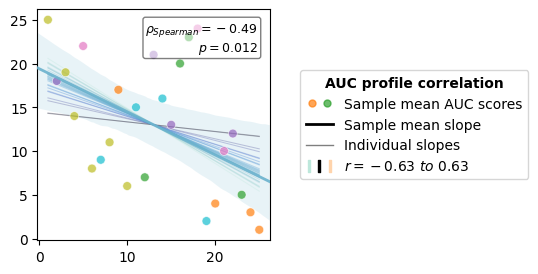

In [10]:
from matplotlib.colors import Normalize

def plot_profilecorr_indiv(mod1, metric1, mod2, metric2, fq=None, meg_measure="aec", ax=None, 
                           xlabel="", ylabel="", title="", 
                           parc="Schaefer200", stat="auc", vmin=None, vmax=None, robust_z=True, rank=False):
    
    # checks
    assert mod1 in ["mri", "meg"] and mod2 in ["mri", "meg"], "mod1 and mod2 must be 'mri' or 'meg'"
    assert metric1 in ["original", "inverted"] and metric2 in ["original", "inverted"], "metric1 and metric2 must be 'original' or 'inverted'"
    if "meg" in [mod1, mod2] and fq is None:
        raise ValueError("fq must be specified when mod1 or mod2 is 'meg'")
    
    # fig
    if ax is None:
        fig, ax = plt.subplots(figsize=(3,3))
    
    # variables to get
    val_mean = "mean" if not robust_z else "mean_rz"
    val_indiv = "val" if not robust_z else "val_rz"
    # data1 (x)
    if mod1 == "mri":
        y = neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], metric1, stat, val_mean), REF_NAMES_PET].mean()
        ys = (
            neofc_ya_mri_pet_indivstats
            .loc[(parc, "pearson", "all", [1,2], metric1, stat, val_indiv, subs), REF_NAMES_PET]
            .groupby("id").mean()
        )
    else:
        y = neofc_ya_meg_pet_groupstats.loc[(parc, meg_measure, "all", fq, metric1, stat, val_mean), REF_NAMES_PET]
        ys = (
            neofc_ya_meg_pet_indivstats
            .loc[(parc, meg_measure, "all", fq, metric1, stat, val_indiv, subs), REF_NAMES_PET]
            .groupby("id").mean()
        )
    # data2 (y)
    if mod2 == "mri":
        x = neofc_ya_mri_pet_groupstats.loc[(parc, "pearson", "all", [1,2], metric2, stat, val_mean), REF_NAMES_PET].mean()
        xs = (
            neofc_ya_mri_pet_indivstats
            .loc[(parc, "pearson", "all", [1,2], metric2, stat, val_indiv, subs), REF_NAMES_PET]
            .groupby("id").mean()
        )
    else:
        x = neofc_ya_meg_pet_groupstats.loc[(parc, meg_measure, "all", fq, metric2, stat, val_mean), REF_NAMES_PET]
        xs = (
            neofc_ya_meg_pet_indivstats
            .loc[(parc, meg_measure, "all", fq, metric2, stat, val_indiv, subs), REF_NAMES_PET]
            .groupby("id").mean()
        )
    # results
    A = f"{mod1}{'-'+fq if mod1 == 'meg' else ''}_{metric1}"
    B = f"{mod2}{'-'+fq if mod2 == 'meg' else ''}_{metric2}"
    r_indiv, p_indiv = neofc_ya_mrimeg_indivprofile.loc[A, B, :].values.T
    r_mean, p_mean = neofc_ya_mrimeg_groupprofile.loc[A, B]
    
    # cmap
    cmap = sn.color_palette("icefire", as_cmap=True)
    vmin, vmax = (-np.abs(r_indiv).max() if vmin is None else vmin, np.abs(r_indiv).max() if vmax is None else vmax)
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # plot group
    print(spearmanr(x, y))
    sn.scatterplot(
        x=x if not rank else x.rank(), 
        y=y if not rank else y.rank(), 
        ax=ax, 
        color=[REF_COLORS_BY_MAP[m] for m in REF_NAMES_PET], 
        s=40,
        alpha=0.7,
        zorder=10
    )
    sn.regplot(
        x=x if not rank else x.rank(), 
        y=y if not rank else y.rank(), 
        ax=ax, 
        color=cmap(norm(r_mean)), 
        line_kws={"linewidth": 2, "zorder": 11, "alpha": 0.9, "linestyle": "-"},
        scatter=False,
        truncate=False,
        #ci=False,
    )
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # plot individual
    for i, sub in enumerate(subs):
        sn.regplot(
            x=xs.loc[sub] if not rank else xs.loc[sub].rank(),
            y=ys.loc[sub] if not rank else ys.loc[sub].rank(),
            ax=ax,
            scatter=False,
            ci=False,
            line_kws={
                "linestyle": "-",
                "color": cmap(norm(r_indiv[i])), 
                "alpha": 0.3, 
                "linewidth": 0.75,
                "zorder": 1
            }
        )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # annotate
    p = "< 0.001" if p_mean < 0.001 else f"= {p_mean:.3f}"
    ax.annotate(
        text=f"$\\rho_{{Spearman}} = {r_mean:.2f}$\n"
             f"$p {p}$",
        xy=(0.05, 0.95) if r_mean > 0 else (0.95, 0.95),
        xycoords="axes fraction",
        ha="left" if r_mean > 0 else "right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.5, boxstyle="round,pad=0.2"),
        zorder=12
    )
    
    # layout
    ax.set_title(title, weight="semibold")
    ax.set_ylabel(ylabel, weight="semibold")
    ax.set_xlabel(xlabel, weight="semibold")
        
    # legend
    if ax.get_subplotspec().is_last_col():
        
        # legend 1:
        line_handle = (
            plt.Line2D([0], [1], color=cmap(norm(norm.vmin)), marker="$|$", markersize=9, linestyle="none"),
            plt.Line2D([0], [1], color="k", marker="$|$", markersize=9, linestyle="none"),
            plt.Line2D([0], [1], color=cmap(norm(norm.vmax)), marker="$|$", markersize=9, linestyle="none"),
        )
        point_handle = (
            plt.Line2D([0], [1], color=REF_COLORS_BY_MAP["NET"], marker="o", markersize=5, linestyle="none", alpha=0.7),
            plt.Line2D([0], [1], color=REF_COLORS_BY_MAP["VMAT2"], marker="o", markersize=5, linestyle="none", alpha=0.7),
        )
        handles_dict = {
            "Sample mean AUC scores": point_handle,
            "Sample mean slope": plt.Line2D([0], [1], color="k", marker="none", linestyle="-", linewidth=2),
            "Individual slopes": plt.Line2D([0], [1], color="k", marker="none", linestyle="-", linewidth=1, alpha=0.5),
            f"$r = {norm.vmin:.2f}\ to\ {norm.vmax:.2f}$": line_handle
        }
        ax.legend(
            handles_dict.values(), handles_dict.keys(), 
            loc="center left", bbox_to_anchor=(1.1, 0.5),
            title="AUC profile correlation",
            title_fontproperties={"weight": "semibold", "size": 10},
            handler_map={
                point_handle: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.1),
                line_handle: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.2)
            }
        )
        
plot_profilecorr_indiv("mri", "inverted", "meg", "original", fq="beta", rank=True)

#### MRI vs MEG combinations in beta band

SignificanceResult(statistic=0.5553846153846154, pvalue=0.00395097193227781)
SignificanceResult(statistic=0.7692307692307693, pvalue=6.9993767826127116e-06)
SignificanceResult(statistic=-0.5253846153846153, pvalue=0.006997085226581306)
SignificanceResult(statistic=-0.4930769230769231, pvalue=0.012263960333497645)


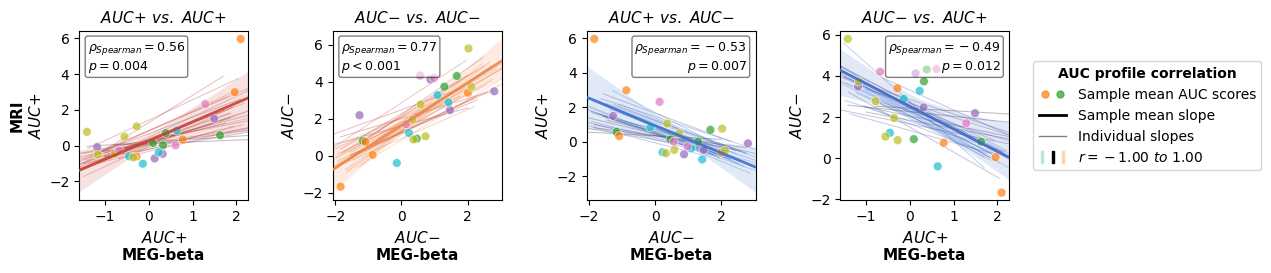

In [11]:
fq = "beta"

fig, axes = plt.subplots(1, 4, figsize=(12, 3), gridspec_kw={"wspace": 0.5})

label_map = {"original": "$AUC\t{+}$", "inverted": "$AUC\t{-}$"}

for i, mod1, metric1, mod2, metric2 in [
    (0, "mri", "original", "meg", "original"),
    (1, "mri", "inverted", "meg", "inverted"),
    (2, "mri", "original", "meg", "inverted"),
    (3, "mri", "inverted", "meg", "original"),
]:

    axes[i].set_box_aspect(1)
    plot_profilecorr_indiv(
        mod1, metric1, mod2, metric2, 
        fq=fq, 
        ax=axes[i],
        vmin=-1, 
        vmax=1,
        rank=False
    )

    # y label
    if i == 0:
        axes[i].set_ylabel(f"{mod1.upper()}\n{label_map[metric1]}", weight="semibold", fontsize=11)
    else:
        axes[i].set_ylabel(f"{label_map[metric1]}", fontsize=11)
    # x label
    axes[i].set_xlabel(f"{label_map[metric2]}\n{mod2.upper()}-{fq}", weight="semibold", fontsize=11)
    # title
    axes[i].set_title(f"{label_map[metric1]} $vs.$ {label_map[metric2]}", weight="semibold", fontsize=11)
    
fig.savefig(wd / "plots" / "comp_mri_meg" / f"indivprofile{fq}_parc-{parc}.pdf", bbox_inches="tight")

#### MRI vs MEG combinations in all bands

SignificanceResult(statistic=0.26384615384615384, pvalue=0.20251547162065686)
SignificanceResult(statistic=0.5661538461538461, pvalue=0.0031763397406322624)
SignificanceResult(statistic=-0.35, pvalue=0.08631994521775348)
SignificanceResult(statistic=-0.19076923076923075, pvalue=0.36101054681468103)
SignificanceResult(statistic=0.2684615384615385, pvalue=0.1944383348505003)
SignificanceResult(statistic=0.6823076923076923, pvalue=0.00017186541538249153)
SignificanceResult(statistic=-0.35, pvalue=0.08631994521775348)
SignificanceResult(statistic=-0.30000000000000004, pvalue=0.14511308137364481)


/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_14781/568310835.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[r, c].legend().set_visible(False)


SignificanceResult(statistic=0.19, pvalue=0.3629865382459393)
SignificanceResult(statistic=0.5761538461538462, pvalue=0.0025765355357845778)
SignificanceResult(statistic=-0.1815384615384615, pvalue=0.38513664752146737)
SignificanceResult(statistic=-0.3553846153846154, pvalue=0.08126735918803056)


/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_14781/568310835.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[r, c].legend().set_visible(False)


SignificanceResult(statistic=0.5553846153846154, pvalue=0.00395097193227781)
SignificanceResult(statistic=0.7692307692307693, pvalue=6.9993767826127116e-06)
SignificanceResult(statistic=-0.5253846153846153, pvalue=0.006997085226581306)
SignificanceResult(statistic=-0.4930769230769231, pvalue=0.012263960333497645)


/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_14781/568310835.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[r, c].legend().set_visible(False)


SignificanceResult(statistic=0.1623076923076923, pvalue=0.4382499479372728)
SignificanceResult(statistic=0.5507692307692308, pvalue=0.0043288477428478885)
SignificanceResult(statistic=-0.3146153846153846, pvalue=0.12558660108939315)
SignificanceResult(statistic=-0.23846153846153845, pvalue=0.2510011134189242)


/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_14781/568310835.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[r, c].legend().set_visible(False)


SignificanceResult(statistic=0.13999999999999999, pvalue=0.504477192636605)
SignificanceResult(statistic=0.4646153846153846, pvalue=0.019287095935427063)
SignificanceResult(statistic=-0.15076923076923077, pvalue=0.4719066833093053)
SignificanceResult(statistic=-0.2453846153846154, pvalue=0.2370897001583282)


/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_14781/568310835.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[r, c].legend().set_visible(False)


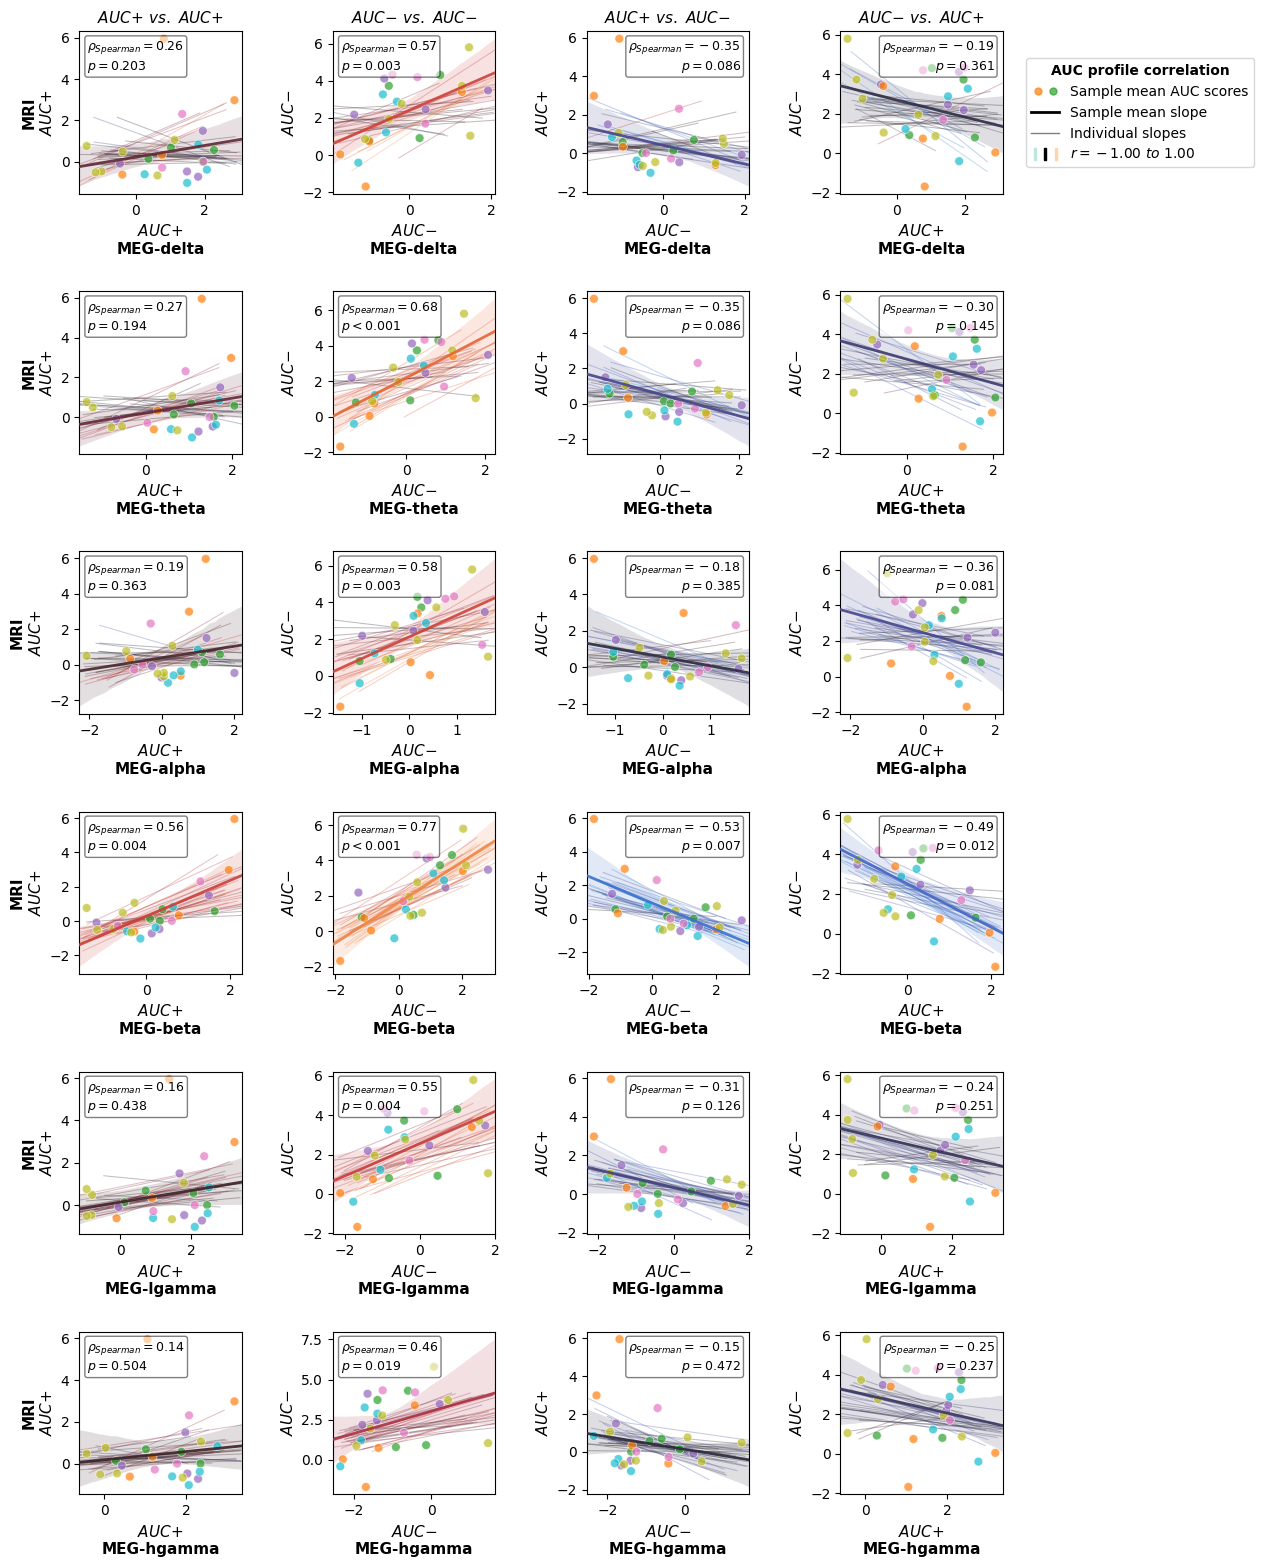

In [12]:
fig, axes = plt.subplots(6, 4, figsize=(12, 19), gridspec_kw={"wspace": 0.5, "hspace": 0.6})

label_map = {"original": "$AUC\t{+}$", "inverted": "$AUC\t{-}$"}

for r, fq in enumerate(MEG_FQBANDS):
    for c, mod1, metric1, mod2, metric2 in [
        (0, "mri", "original", "meg", "original"),
        (1, "mri", "inverted", "meg", "inverted"),
        (2, "mri", "original", "meg", "inverted"),
        (3, "mri", "inverted", "meg", "original"),
    ]:

        axes[r, c].set_box_aspect(1)
        plot_profilecorr_indiv(
            mod1, metric1, mod2, metric2, 
            fq=fq, 
            ax=axes[r, c],
            vmin=-1, 
            vmax=1
        )

        # y label
        if c == 0:
            axes[r, c].set_ylabel(f"{mod1.upper()}\n{label_map[metric1]}", weight="semibold", fontsize=11)
        else:
            axes[r, c].set_ylabel(f"{label_map[metric1]}", fontsize=11)
        # x label
        axes[r, c].set_xlabel(f"{label_map[metric2]}\n{mod2.upper()}-{fq}", weight="semibold", fontsize=11)
        # title
        if r == 0:
            axes[r, c].set_title(f"{label_map[metric1]} $vs.$ {label_map[metric2]}", weight="semibold", fontsize=11)
        # legend
        if c == 3:
            if not r == 0:
                axes[r, c].legend().set_visible(False)

fig.savefig(wd / "plots" / "comp_mri_meg" / f"indivprofile_parc-{parc}.pdf", bbox_inches="tight")

### Plot: MRI vs MEG "across-subject" correlation

In [13]:
def plot_subcorr(ax, metric, width=1, title="", stat="auc", cmap="icefire", legend=True,
                 color_range=(None, None)):
    data = (
        neofc_ya_mrimeg_subcorr
        .loc[metric, REF_NAMES_PET, MEG_FQBANDS]
    )
    data = data.pivot_table(columns="fqband", index="map")
    data_color = data.loc[REF_NAMES_PET, ("rho", MEG_FQBANDS)]
    data_p = data.loc[REF_NAMES_PET, ("p", MEG_FQBANDS)]
    annot = np.full_like(data_p, "", dtype=str)
    annot[data_p < 0.05] = "☆"
    cax = ax.inset_axes((1.1, 0.7, 0.07, 0.3))
    
    sn.heatmap(
        data_color,
        fmt="",
        ax=ax,
        cmap=cmap,
        center=0,
        vmin=color_range[0],
        vmax=color_range[1],
        cbar_ax=cax,
        cbar_kws={"label": "$\\rho$"},
        linewidths=2,
        xticklabels=MEG_FQBANDS,
        #linecolor="w",
    )
    
    for cat, maps in REF_GROUPS_PET.items():
        # y positions
        y = [l.get_position()[1] for l in ax.get_yticklabels() if l.get_text() in maps]
        # plot line
        for y_pos in y:
            for x_pos in range(annot.shape[1]):
                if annot[int(y_pos), x_pos] != "":
                    ax.plot(
                        x_pos+0.5, y_pos, marker="o", markersize=14, 
                        color="w", linewidth=0
                    )
                    ax.plot(x_pos+0.5, y_pos-0.025, marker=f"${annot[int(y_pos), x_pos]}$",
                            markersize=11, color=REF_COLORS_BY_MAP[maps[0]])

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor",
                       fontsize=11)
    for l in ax.get_yticklabels():
        l.set_color(REF_COLORS_BY_MAP[l.get_text()])
    ax.set_yticklabels([REF_MATH_NAMES[m] for m in REF_NAMES_PET], fontsize=11)
    ax.set_title(title, weight="semibold", pad=10, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # legend
    if legend:
        square_handle = plt.Line2D([0], [0], color=sn.color_palette("icefire", as_cmap=True)(0.9), 
                                   marker="s", markersize=12, linestyle="None")
        star_handle = plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["VMAT2"], marker="$☆$", markersize=10, linestyle="None")
        handles_dict = {
            "$\\rho_{Spearman}$": square_handle,
            "$p < 0.05$": star_handle,
        }   
        axes[-1].legend(
            handles_dict.values(), 
            handles_dict.keys(), 
            title="AUC correlation\n(across subjects)", 
            title_fontproperties={'weight':'semibold', "size": 12},
            loc="center left", bbox_to_anchor=(1.1, 0.5)
        )
        

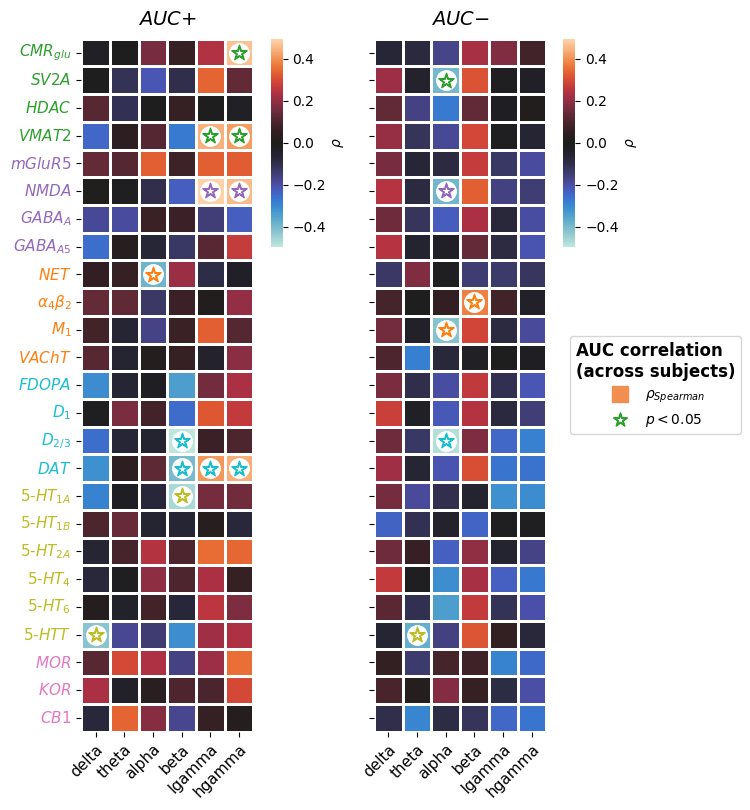

In [14]:
fig, axes = plt.subplots(1,2, figsize=(6,9), gridspec_kw={"wspace": 0.7})

vmax = neofc_ya_mrimeg_subcorr.loc[:, REF_NAMES_PET, MEG_FQBANDS]["rho"].abs().max()
for i, metric in enumerate(["original", "inverted"]):
        
    plot_subcorr(axes[i], metric, width=1, title="$AUC\t{+}$" if metric == "original" else "$AUC\t{-}$",
                 legend=i==1, color_range=(-vmax, vmax))
    if i == 1:
        axes[i].set_yticklabels([])
   
# save
fig.savefig(wd / "plots" / "comp_mri_meg" / f"subjectcorr_parc-{parc}.pdf", bbox_inches="tight")